# Notebook 19 (V4_3) — Notebook 15 AHP plots at $T_{solved}=110$

This notebook fixes the calibration at Notebook 15's selected `pathwise_hi_exp_pi075` parameters and reproduces its four figure groups on a hard-valid 110-period solution. The first 15 periods remain the AHP evidence window; periods 16–110 are shown as the unscored tail.

The calibration search is not rerun. Instead, the selected equilibrium is extended using the successful numerical strategy documented by Notebook 17.

## Why this solves at 110

Notebook 15 cold-solves finalists at `T=30` with a scratch buffer. Notebook 17 demonstrates that the same branch remains hard-valid beyond 110 when it instead uses:

- `n_buffer = 0`, so the requested and reported solved horizons coincide;
- the decay-consistent local log-linear artificial successor for period `T+1`;
- warm continuation through `30, 45, 60, 70, 80, 90, 100, 105, 110`; and
- an escalating branch-iteration schedule of `60, 200` if a stage needs a retry.

The AHP accounting below also replaces Notebook 15's incidental call to `nfa_decomposition` with the direct equilibrium identity `NFA = A - Q_US`. This avoids invoking an unrelated terminal fundamental-value recursion at the long horizon.

In [1]:
function nb19_notebook_project_dir(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        for candidate in (dir, joinpath(dir, "Codes"))
            script = joinpath(candidate, "Two_country_production",
                              "19_v9_ahp_pattern_T110_replication.jl")
            isfile(script) && return candidate
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate the Notebook 19 script")
        dir = parent
    end
end

nb19_project_dir = nb19_notebook_project_dir()
include(joinpath(nb19_project_dir, "Two_country_production",
                 "19_v9_ahp_pattern_T110_replication.jl"))

  Activating 

Project directory:             /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



Output directory:              /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_T110_replication
Requested solved horizon:      110
Scratch buffer:                0
Warm-continuation horizons:    

[30, 45, 60, 70, 80, 90, 100, 105, 110]
Branch-iteration schedule:     [60, 200]
Solving T=30, buffer=0, branch_iters=60, warm_T=


...

Solving T=70, buffer=0, branch_iters=60, warm_T=60
Solving T=80, buffer=0, branch_iters=60, warm_T=70


Solving T=90, buffer=0, branch_iters=60, warm_T=80
Solving T=100, buffer=0, branch_iters=60, warm_T=90


Solving T=105, buffer=0, branch_iters=60, warm_T=100
Solving T=110, buffer=0, branch_iters=60, warm_T=105



NOTEBOOK 19 — NOTEBOOK 15 AHP FIGURES ON THE T=110 CONTINUATION
Final max u residual:             3.557e-07
Final max BGP residual:           9.985e-10
Max first-window replication err: 6.431e-10
t=15 rebased NFA:                 -0.037937
t=15 net VA / cumulative CA:      -0.048656 / +0.010719
|VA| / |CA|:                      4.539


State-specific nu_b_eff range:    [0.172235, 1.660653]
Maximum common-growth log gap:    4.088e-09
Hard-valid T=110 solution:         true
Artifacts written to:             /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_T110_replication


## Notebook 15 figure replication on the full solution

The original styling is retained: the first-window series are opaque and the post-15 tail is muted.

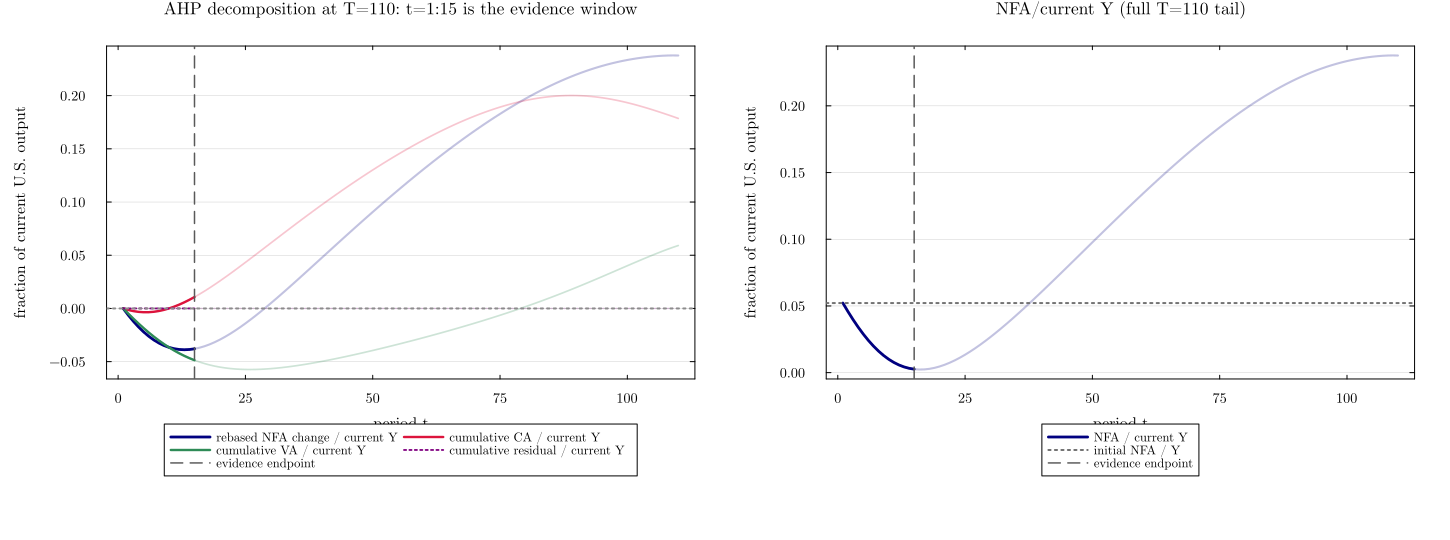

In [2]:
fig_ahp_two_panel

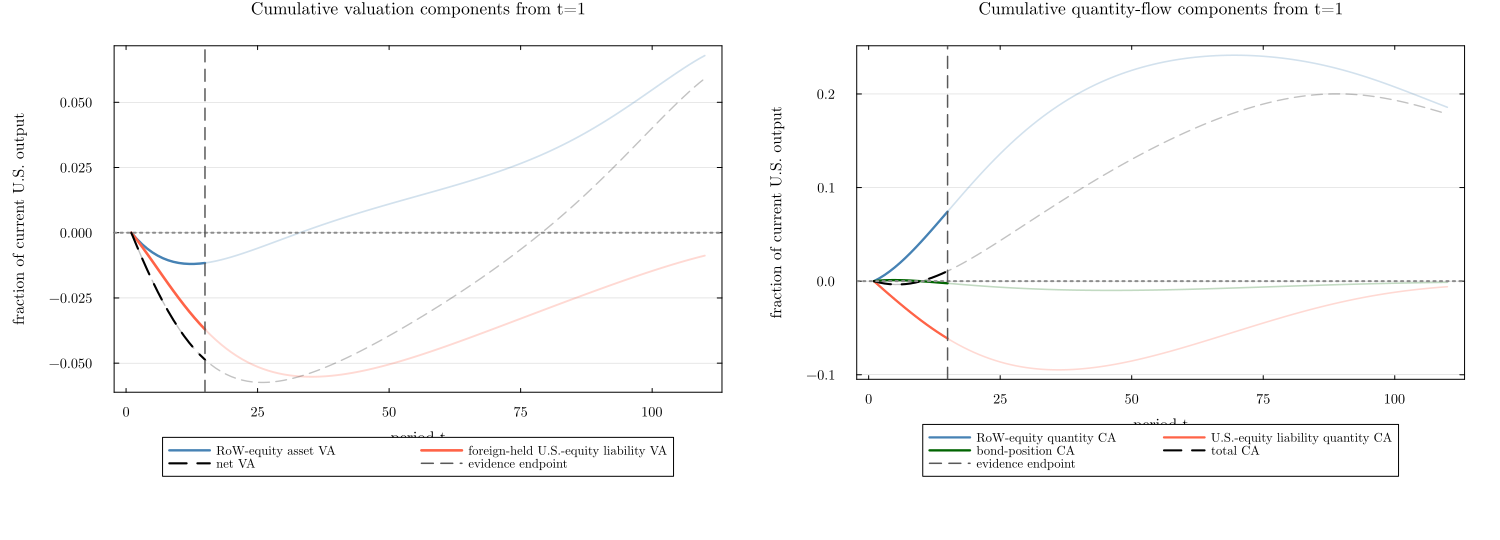

In [3]:
fig_subcomponents

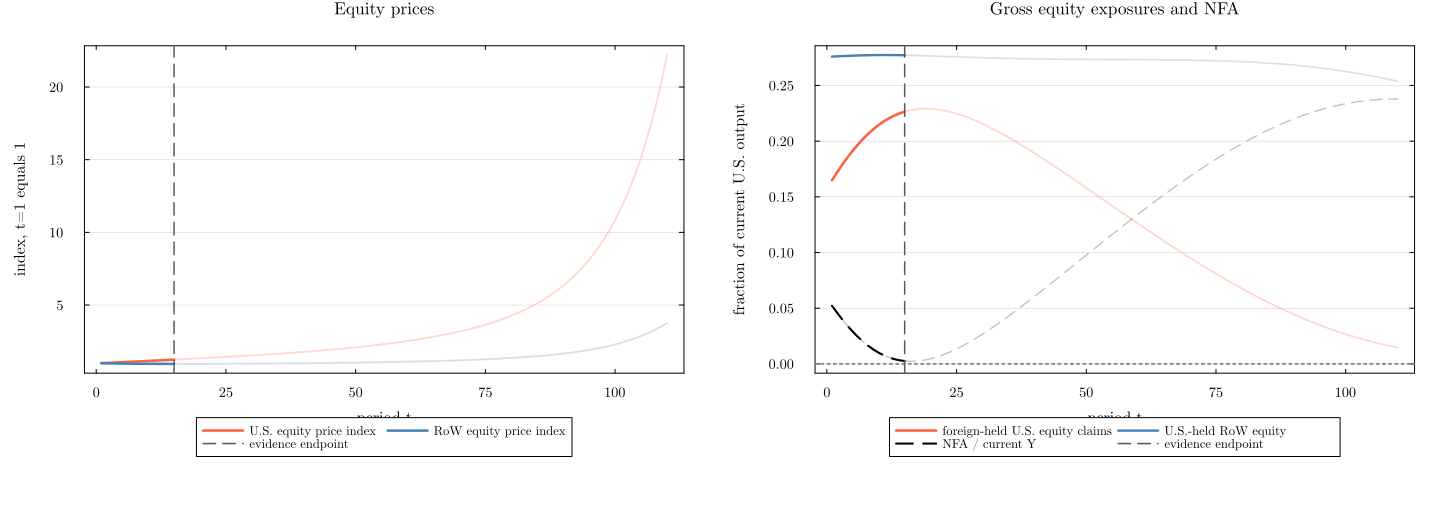

In [4]:
fig_prices_exposures

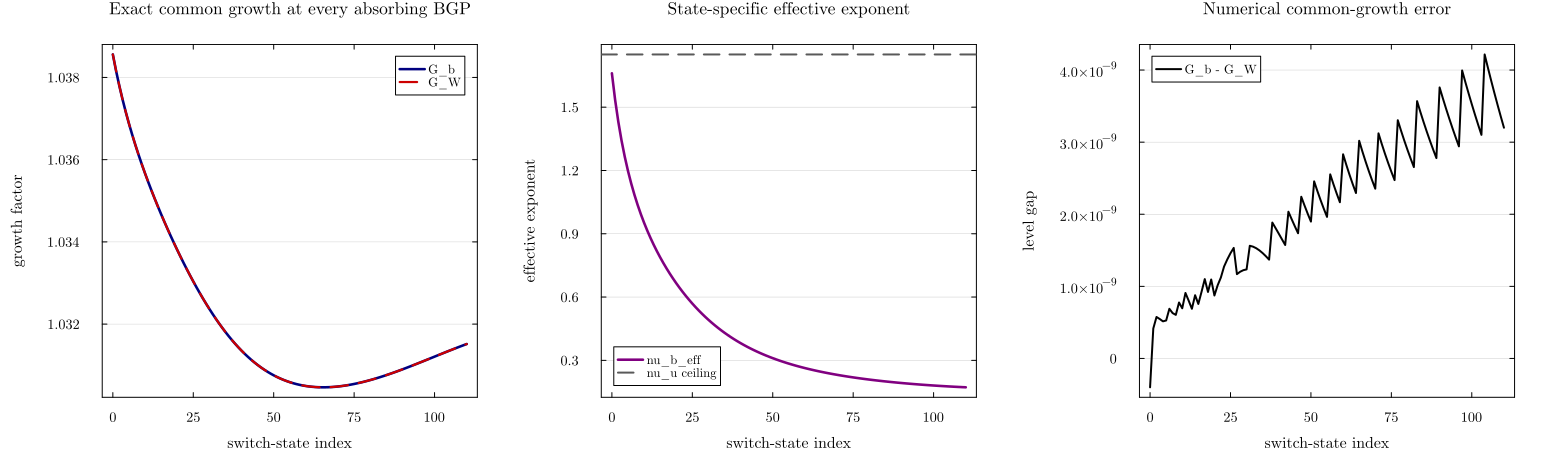

In [5]:
fig_common_growth

## Certification summary

The assertions in the solve cell require both the Notebook 15/17 hard-validity gates and a first-window match to Notebook 15 within `2e-5`.

In [6]:
@printf("T_solved:                         %d\n", T_solved)
@printf("Hard-valid solution:              %s\n", best_validity.valid)
@printf("Maximum u residual:               %.3e\n", best_result.max_u_residual)
@printf("Maximum BGP residual:             %.3e\n", best_result.max_bgp_residual)
@printf("First-window replication error:   %.3e\n", nb19_max_first_window_error)
@printf("t=15 rebased NFA / current Y:     %+.6f\n", best_metrics.target_rebased_nfa)
@printf("t=15 net VA / cumulative CA:      %+.6f / %+.6f\n",
        best_metrics.target_net_va, best_metrics.target_ca)
@printf("Maximum common-growth log gap:    %.3e\n", best_common_summary.max_log_gap)
println("Artifacts:                         ", NB19_OUTDIR)

T_solved:                         110
Hard-valid solution:              true
Maximum u residual:               3.557e-07
Maximum BGP residual:             9.985e-10
First-window replication error:   6.431e-10
t=15 rebased NFA / current Y:     -0.037937
t=15 net VA / cumulative CA:      -0.048656 / +0.010719
Maximum common-growth log gap:    4.088e-09
Artifacts:                         /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_T110_replication
